# Conic point triplets — decomposition & extraction

The CCGA conic **point triplet** `T = p1 ^ p2 ^ p3` (grade 3). We

- build `T` and verify its closed form (§1),
- give a **closed-form inverse** that extracts the circumcircle (center, radius)
  and the three points (§2),
- analyse the three input families: real / imaginary / ideal (§3-5),
- visualize (§6).

Unifying square law (generalises the point pair):
$$T^2 = -\det(\mathrm{Gram}),\quad \mathrm{Gram}_{ij}=p_i\cdot p_j,\quad
\text{(plain points) } T^2=\tfrac14\,d_{12}^2 d_{13}^2 d_{23}^2.$$

Select the **CCGA (.venv)** kernel.

In [1]:
import numpy as np, sympy as sp
import matplotlib.pyplot as plt
from ccga.algebra import e1, e2, eo, einf, einf1, einf2, einf3, Iinfd, Iod, I_inv
from ccga.point import point
from ccga.objects import make_ideal_point
from ccga.operations import grades, is_zero
from ccga.classify import reality, ipns_to_coeffs

def conic_point(x, y, R=0.0):
    # conic point with signed radius^2 R  (p^2 = R)
    return eo + x*e1 + y*e2 + (x**2/2)*einf1 + (y**2/2)*einf2 + x*y*einf3 - (R/2)*einf

def sq(mv):
    s = mv*mv
    return float(s.e) if 0 in [bin(k).count('1') for k in s.keys()] else 0.0

def dot(a, b):
    return float((a | b).e)

def gram_square(pts):
    # -det(Gram) should equal T^2
    G = np.array([[dot(a, b) for b in pts] for a in pts])
    return -np.linalg.det(G)

def circumcircle(T):
    # closed-form GA inverse: grade-1 circumcircle IPNS  s = Iod | ((T^Iinfd) I^-1)
    A, B, Cc, D, E, F = ipns_to_coeffs(Iod | ((T ^ Iinfd) * I_inv))
    if abs(A) < 1e-9:
        return None                          # line / degenerate
    cx, cy = -D/(2*A), -E/(2*B)
    R2 = cx*cx + cy*cy - F/A
    return dict(center=(cx, cy), R2=R2,
                reality=('real' if R2 > 1e-9 else 'imaginary' if R2 < -1e-9 else 'point'))

def extract_points(T, tol=1e-7):
    # the point-embeddings in span{p1,p2,p3} are exactly the 3 vertices (when they are plain points)
    x, y = sp.symbols('x y', real=True)
    try:
        sols = sp.solve([sp.expand(v) for v in (point(x, y) ^ T).values()], [x, y], dict=True)
    except Exception:
        return 'solve failed'
    out = []
    for d in sols:
        if x not in d or y not in d:
            return 'non-isolated (degenerate / collinear)'
        vx, vy = complex(d[x]), complex(d[y])
        if abs(vx.imag) + abs(vy.imag) < tol:
            out.append((round(vx.real, 4), round(vy.real, 4)))
        else:
            out.append('complex')
    return out

def decompose(T):
    cc = circumcircle(T); pts = extract_points(T)
    out = dict(circumcircle=cc, points=pts, directions=None, edge_spokes=None)
    if isinstance(cc, dict) and isinstance(pts, list) and pts and all(isinstance(p, tuple) for p in pts):
        Cn = np.array(cc['center']); R = abs(cc['R2'])**0.5
        if R > 1e-9:
            out['directions'] = [tuple(np.round((np.array(p) - Cn)/R, 3)) for p in pts]
        P = [np.array(p) for p in pts]
        if len(P) == 3:
            w1, w2 = P[0]-P[2], P[1]-P[2]; n1, n2 = np.linalg.norm(w1), np.linalg.norm(w2)
            out['edge_spokes'] = dict(center_vertex=tuple(np.round(P[2], 3)),
                                      rad1=round(n1, 3), dir1=tuple(np.round(w1/n1, 3)),
                                      rad2=round(n2, 3), dir2=tuple(np.round(w2/n2, 3)))
    return out

def report(T, label=''):
    print('---', label, '---')
    print('  grade   :', grades(T), '  T^2 :', round(sq(T), 4))
    print('  reality :', reality(T), '  finite:', not is_zero(T | einf))
    print('  decompose:', decompose(T))

## 1. Construction & closed form

`p_k = conic_point(...)`, `T = p1 ^ p2 ^ p3` (grade 3). Forward closed form
(one vertex as center, `C = p3`, spokes `w_i = rad_i*dir_i`):
$$T = (W_1+Q_1)\wedge(W_2+Q_2)\wedge C,$$
with `W_i` the tangent `dC[w_i]` and `Q_i` the ideal point of `w_i`.

In [2]:
# numeric: T^2 == -det(Gram) ; plain points -> 1/4 * prod of squared distances
pts = [point(0, 0), point(4, 0), point(1, 3)]
T = pts[0] ^ pts[1] ^ pts[2]
print('grade(T) =', grades(T), '  T^2 =', round(sq(T), 4), '  -det(Gram) =', round(gram_square(pts), 4))
d2 = lambda a, b: (a[0]-b[0])**2 + (a[1]-b[1])**2
A, B, Cc = (0, 0), (4, 0), (1, 3)
print('1/4 * d12^2 d13^2 d23^2 =', 0.25*d2(A, B)*d2(A, Cc)*d2(B, Cc))

grade(T) = [3]   T^2 = 720.0   -det(Gram) = 720.0
1/4 * d12^2 d13^2 d23^2 = 720.0


In [3]:
# symbolic: T = (W1+Q1)^(W2+Q2)^C   with C = p3
cx, cy, r1, a1, r2, a2 = sp.symbols('cx cy r1 a1 r2 a2', real=True)
w1x, w1y = r1*sp.cos(a1), r1*sp.sin(a1)
w2x, w2y = r2*sp.cos(a2), r2*sp.sin(a2)
Csym = conic_point(cx, cy)
Tsym = conic_point(cx+w1x, cy+w1y) ^ conic_point(cx+w2x, cy+w2y) ^ Csym
def Wv(wx, wy): return wx*e1 + wy*e2 + cx*wx*einf1 + cy*wy*einf2 + (cx*wy+cy*wx)*einf3
def Qv(wx, wy): return (wx**2/2)*einf1 + (wy**2/2)*einf2 + wx*wy*einf3
closed = (Wv(w1x, w1y)+Qv(w1x, w1y)) ^ (Wv(w2x, w2y)+Qv(w2x, w2y)) ^ Csym
print('T == (W1+Q1)^(W2+Q2)^C :',
      all(sp.simplify(sp.expand(c)) == 0 for c in (Tsym - closed).values()))

T == (W1+Q1)^(W2+Q2)^C : True


## 2. Closed-form inverse — extract circumcircle + the three points

`circumcircle(T)` uses the GA closed form `s = Iod | ((T^Iinfd) * I^-1)` (a
grade-1 circle IPNS, comes out `A=B`); `extract_points(T)` solves
`point(x,y)^T = 0`, whose only solutions are the three vertices.

In [4]:
report(T, 'triplet (0,0),(4,0),(1,3)')
print()
print('round-trip: rebuild from extracted points ->',
      grades((point(0,0)^point(4,0)^point(1,3)) - T) == [] )

--- triplet (0,0),(4,0),(1,3) ---
  grade   : [3]   T^2 : 720.0
  reality : real   finite: True


  decompose: {'circumcircle': {'center': (2.0, 1.0), 'R2': 5.0, 'reality': 'real'}, 'points': [(0.0, 0.0), (1.0, 3.0), (4.0, 0.0)], 'directions': [(np.float64(-0.894), np.float64(-0.447)), (np.float64(-0.447), np.float64(0.894)), (np.float64(0.894), np.float64(-0.447))], 'edge_spokes': {'center_vertex': (np.float64(4.0), np.float64(0.0)), 'rad1': np.float64(4.0), 'dir1': (np.float64(-1.0), np.float64(0.0)), 'rad2': np.float64(4.243), 'dir2': (np.float64(-0.707), np.float64(0.707))}}

round-trip: rebuild from extracted points -> True


## 3. Real triplets  (circumcircle `R^2 > 0`)

In [5]:
report(point(0,0) ^ point(4,0) ^ point(1,3), 'plain points -> real circle')
report(conic_point(0,0,1.) ^ conic_point(4,0,1.) ^ conic_point(1,3,1.),
       'real-radius circles R=1 (circle R^2 shrinks but stays > 0)')

--- plain points -> real circle ---
  grade   : [3]   T^2 : 720.0
  reality : real   finite: True


  decompose: {'circumcircle': {'center': (2.0, 1.0), 'R2': 5.0, 'reality': 'real'}, 'points': [(0.0, 0.0), (1.0, 3.0), (4.0, 0.0)], 'directions': [(np.float64(-0.894), np.float64(-0.447)), (np.float64(-0.447), np.float64(0.894)), (np.float64(0.894), np.float64(-0.447))], 'edge_spokes': {'center_vertex': (np.float64(4.0), np.float64(0.0)), 'rad1': np.float64(4.0), 'dir1': (np.float64(-1.0), np.float64(0.0)), 'rad2': np.float64(4.243), 'dir2': (np.float64(-0.707), np.float64(0.707))}}
--- real-radius circles R=1 (circle R^2 shrinks but stays > 0) ---
  grade   : [3]   T^2 : 576.0
  reality : real   finite: True


  decompose: {'circumcircle': {'center': (2.0, 1.0), 'R2': 4.0, 'reality': 'real'}, 'points': [], 'directions': None, 'edge_spokes': None}


## 4. Imaginary triplets  (circumcircle `R^2 < 0`)

Large positive input radius pushes the circumcircle radius² negative -> imaginary
circle. (Reality is set by the configuration, not the input-radius sign alone.)

In [6]:
report(conic_point(0,0,10.) ^ conic_point(4,0,10.) ^ conic_point(1,3,10.),
       'big real-radius circles R=10 -> imaginary circumcircle')

--- big real-radius circles R=10 -> imaginary circumcircle ---
  grade   : [3]   T^2 : -720.0
  reality : imaginary   finite: True


  decompose: {'circumcircle': {'center': (2.0, 1.0), 'R2': -5.0, 'reality': 'imaginary'}, 'points': [], 'directions': None, 'edge_spokes': None}


## 5. Ideal triplets  (ideal inputs, `w = 0`)

In [7]:
report(make_ideal_point(1,0) ^ make_ideal_point(0,1) ^ make_ideal_point(-1,0),
       'three ideal points (degenerate)')
report(point(0,0) ^ point(1,0) ^ point(2,0), 'collinear points (line / degenerate)')

--- three ideal points (degenerate) ---
  grade   : [3]   T^2 : 0.0
  reality : degenerate   finite: False
  decompose: {'circumcircle': None, 'points': [], 'directions': None, 'edge_spokes': None}
--- collinear points (line / degenerate) ---
  grade   : [3]   T^2 : 1.0
  reality : real   finite: True


  decompose: {'circumcircle': None, 'points': 'non-isolated (degenerate / collinear)', 'directions': None, 'edge_spokes': None}


## 6. Visualization

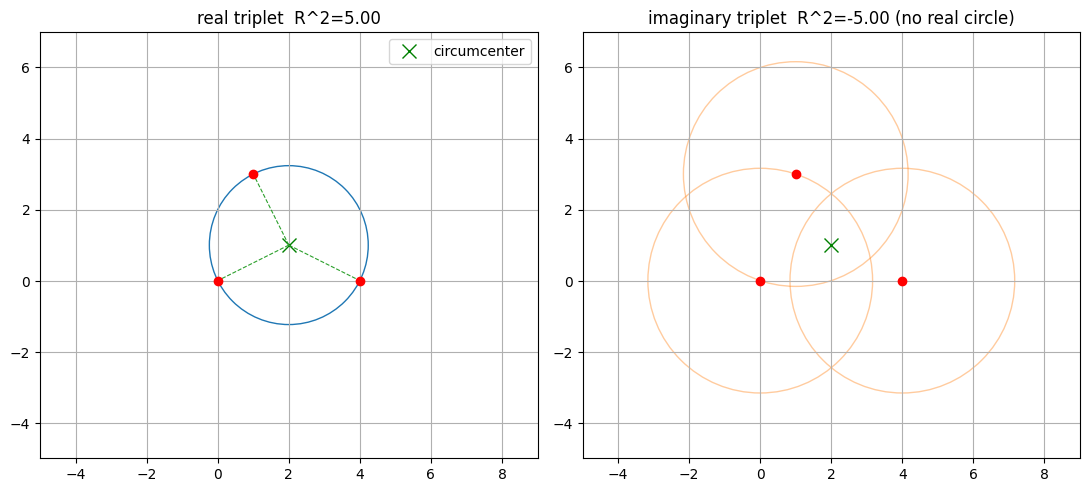

In [8]:
%matplotlib inline
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

# real triplet: 3 points + circumcircle + center + direction spokes
P = [(0, 0), (4, 0), (1, 3)]
T = point(*P[0]) ^ point(*P[1]) ^ point(*P[2])
cc = circumcircle(T); cen = cc['center']; R = cc['R2']**0.5
ax[0].add_patch(plt.Circle(cen, R, fill=False, color='C0'))
ax[0].plot(cen[0], cen[1], 'gx', ms=10, label='circumcenter')
for p in P:
    ax[0].plot([cen[0], p[0]], [cen[1], p[1]], 'C2--', lw=0.8)
    ax[0].plot(*p, 'ro')
ax[0].set_title('real triplet  R^2=%.2f' % cc['R2']); ax[0].legend(loc='upper right')

# imaginary triplet: big circles, no real circumcircle to draw
P = [(0, 0), (4, 0), (1, 3)]
T = conic_point(*P[0], 10.) ^ conic_point(*P[1], 10.) ^ conic_point(*P[2], 10.)
cc = circumcircle(T)
for p in P:
    ax[1].plot(*p, 'ro'); ax[1].add_patch(plt.Circle(p, 10**0.5, fill=False, color='C1', alpha=0.4))
ax[1].plot(*cc['center'], 'gx', ms=10)
ax[1].set_title('imaginary triplet  R^2=%.2f (no real circle)' % cc['R2'])

for a in ax:
    a.set_aspect('equal'); a.grid(True); a.set_xlim(-5, 9); a.set_ylim(-5, 7)
plt.tight_layout(); plt.show()

## Your scratch space